## 01 — EDA Fundamentals: Quality · Distributions · Correlations

**Dataset:** `ecom_shop.csv.gz` — E-commerce events, January 2021

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
PALETTE  = 'muted'
FIG_SIZE = (12, 5)
sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.05)
FIGURES_PATH = '../outputs/figures/'

---
### Phase 1 — Data Quality & Ingestion

#### 1.1 Load and parse timestamps

In [5]:
df = pd.read_csv('../data/raw/ecom_shop.csv', parse_dates=['timestamp'])

#### 1.2 Schema overview

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549020 entries, 0 to 549019
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   timestamp           549020 non-null  datetime64[ns]
 1   user_id             549020 non-null  float64       
 2   event               549020 non-null  object        
 3   category            549020 non-null  object        
 4   country             549020 non-null  object        
 5   source              549020 non-null  object        
 6   is_old_user         549020 non-null  bool          
 7   session_id          549020 non-null  object        
 8   session_number      549020 non-null  int64         
 9   page_location       549020 non-null  object        
 10  page_location_cats  549020 non-null  object        
 11  event_order         549020 non-null  int64         
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 46.6+ MB


#### 1.3 Duplicate detection

In [80]:
n_dup_rows = df.duplicated().sum()
print(f"Duplicate rows : {n_dup_rows:,}")

Duplicate rows : 0


#### 1.4 Temporal consistency

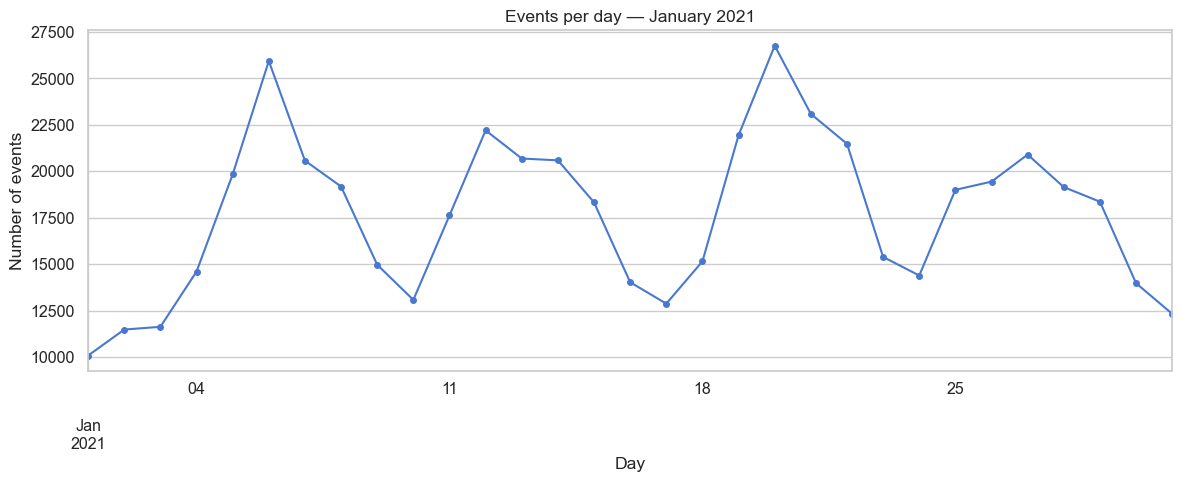

In [81]:
# Events per day
daily_counts = df.resample('D', on='timestamp').size().rename('n_events')

fig, ax = plt.subplots(figsize=FIG_SIZE)
daily_counts.plot(ax=ax, marker='o', linewidth=1.5, markersize=4)
ax.set_title('Events per day — January 2021')
ax.set_ylabel('Number of events')
ax.set_xlabel('Day')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p1_events_per_day.png', dpi=120)
plt.show()

 - No days with zero events → data is continuous.
- Activity is relatively stable.
- No extreme outliers or long gaps that would break session continuity.

The temporal coverage is consistent, so we do not need to adjust for missing days when building session sequences or transition matrices.

#### 1.5 Time features

In [82]:
df['hour']       = df['timestamp'].dt.hour
df['dayofweek']  = df['timestamp'].dt.dayofweek   # 0 = Monday
df['dayname']    = df['timestamp'].dt.day_name()
df['date']       = df['timestamp'].dt.date

df[['timestamp','hour','dayofweek','dayname', 'date']].head(3)

,timestamp,hour,dayofweek,dayname,date
0,2021-01-20 11:04:59.887247,11,2,Wednesday,2021-01-20
1,2021-01-20 11:04:59.887247,11,2,Wednesday,2021-01-20
2,2021-01-20 11:05:05.002377,11,2,Wednesday,2021-01-20


---
### Phase 2 — Univariate Distributions & Temporal Patterns

#### 2.1 Distributions of `session_number` per user

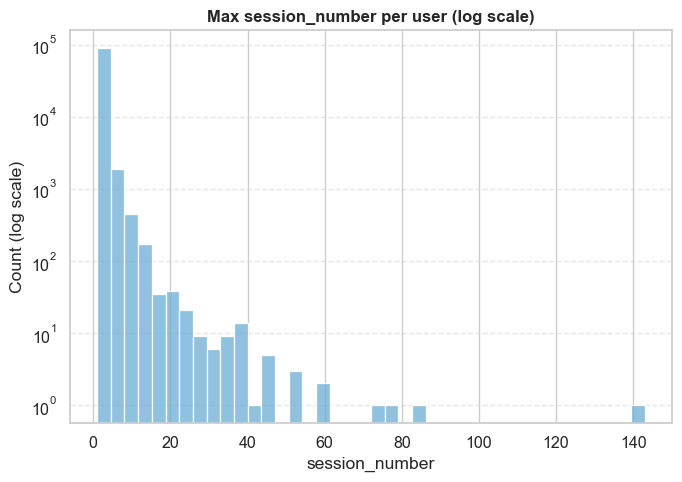

In [83]:
fig, ax = plt.subplots(figsize=(7, 5))

s = df.groupby('user_id')['session_number'].max()
sns.histplot(s, bins=40, kde=False, ax=ax, color='#6baed6')
ax.set_yscale('log')
ax.set_title('Max session_number per user (log scale)', fontsize=12, weight='bold')
ax.set_xlabel('session_number')
ax.set_ylabel('Count (log scale)')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p2_session_number_dist.png', dpi=120)
plt.show()

- Most users are one‑time visitors (90%+).
- As session_number increases, the count drops sharply
- Very few users reach 10 or more sessions; the tail extends to around 140 sessions, but with extremely low counts.


#### 2.2 Categorical distributions — bar charts

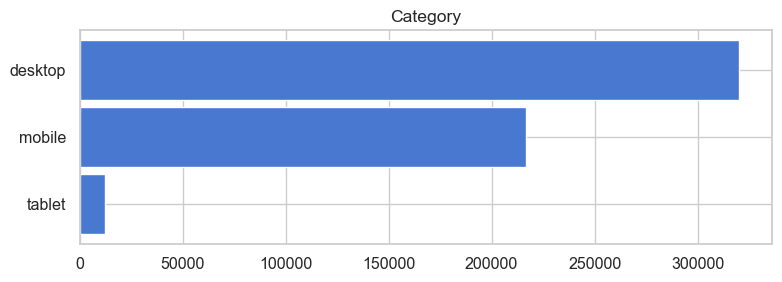

In [84]:
# Category
vc = df['category'].value_counts()
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(range(len(vc)), vc.values, height=0.9)
ax.set_yticks(range(len(vc)))
ax.set_yticklabels(vc.index)
ax.invert_yaxis()
ax.set_title('Category')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p3_category.png', dpi=120)
plt.show()

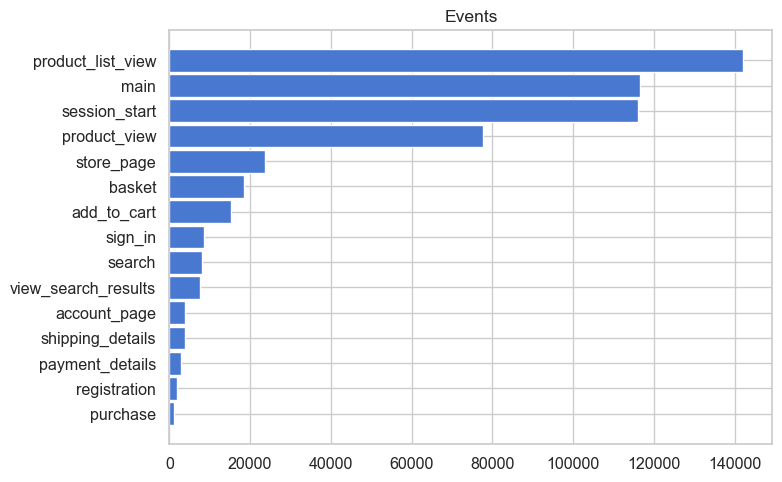

In [85]:
#Events
vc = df['event'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(range(len(vc)), vc.values, height=0.9)
ax.set_yticks(range(len(vc)))
ax.set_yticklabels(vc.index)
ax.invert_yaxis()
ax.set_title('Events')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p4_events.png', dpi=120)
plt.show()

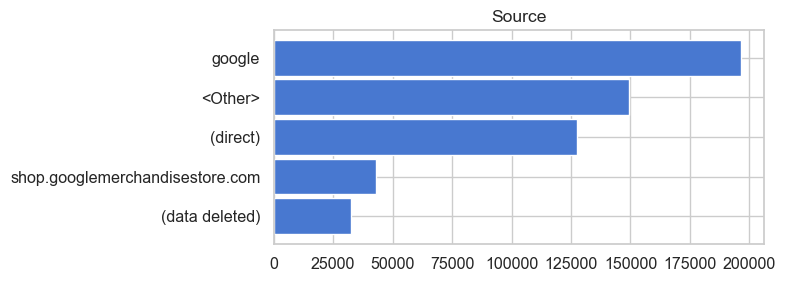

In [86]:
#Source
vc = df['source'].value_counts()
fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(range(len(vc)), vc.values, height=0.9)
ax.set_yticks(range(len(vc)))
ax.set_yticklabels(vc.index)
ax.invert_yaxis()
ax.set_title('Source')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p5_sources.png', dpi=120)
plt.show()

#### 2.3 Rare events detection

In [87]:
event_pct = df['event'].value_counts(normalize=True) * 100

rare_events = event_pct[event_pct < 1]

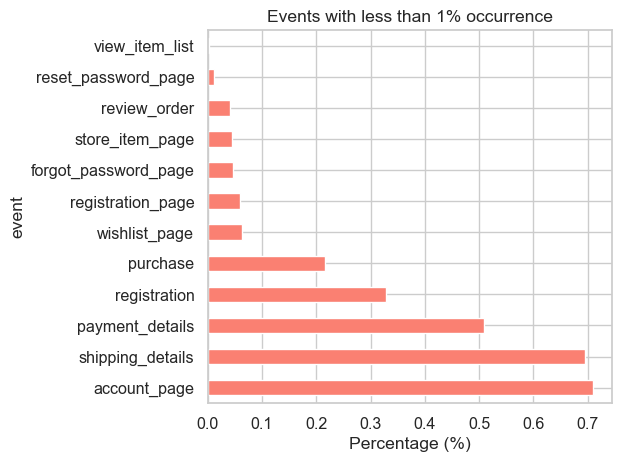

In [88]:
rare_events.plot(kind='barh', y='percentage', legend=False, color='salmon')
plt.title('Events with less than 1% occurrence')
plt.xlabel('Percentage (%)')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}p6_rare_events.png', dpi=120)
plt.show()

Several events have very low frequency (<1% of total). For later modeling (Markov chains), we need to handle them properly:

- `purchase`, `registration` — they are critical for conversion analysis and will likely be kept as separate states.
- The rest (`account_page`, `shipping_details`, `payment_details`, `wishlist_page`, `registration_page`, `forgot_password_page`, `store_item_page`, `review_order`, `reset_password_page`, `view_item_list`) are less critical. A possible approach is to merge them into a single category called `other` to reduce state space and avoid sparse transition matrices. This decision will be confirmed in later phases.

#### 2.4 New vs Old users

In [89]:
print(df['is_old_user'].value_counts(normalize=True) * 100)

is_old_user
False    89.983243
True     10.016757
Name: proportion, dtype: float64


The variable `is_old_user` shows a strong class imbalance (90% new users). Therefore, behavioral comparisons will be carried out in later phases using techniques such as bootstrap on transition matrices.

---
### Phase 3 — Multivariate Analysis

#### 3.1 Session-level correlation matrix

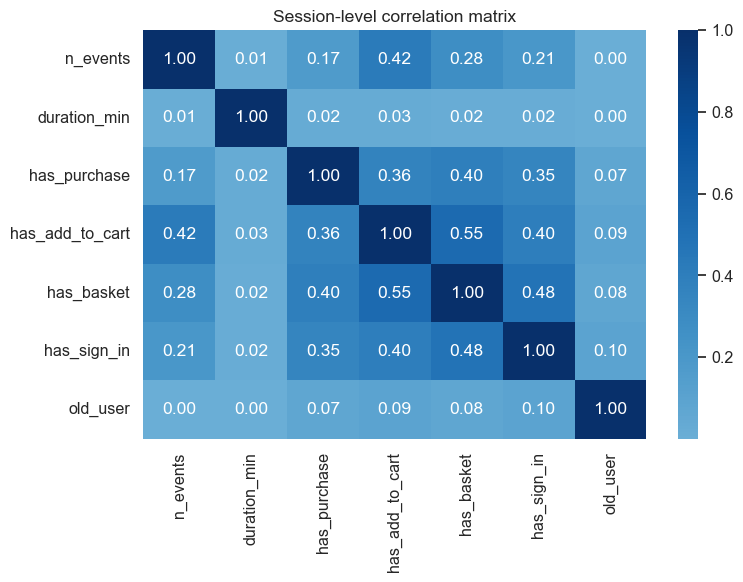

In [90]:
session_features = df.groupby('session_id').agg(
    n_events=('event_order', 'max'),
    has_purchase=('event', lambda x: (x == 'purchase').any()),
    has_add_to_cart=('event', lambda x: (x == 'add_to_cart').any()),
    has_basket=('event', lambda x: (x == 'basket').any()),
    has_sign_in=('event', lambda x: (x == 'sign_in').any()),
    device=('category', 'first'),
    old_user=('is_old_user', 'first'),
    duration_min=('timestamp', lambda x: (x.max() - x.min()).total_seconds() / 60)
).reset_index()

num_cols = ['n_events', 'duration_min', 'has_purchase', 'has_add_to_cart', 'has_basket', 'has_sign_in', 'old_user']
for col in ['has_purchase', 'has_add_to_cart', 'has_basket', 'has_sign_in', 'old_user']:
    session_features[col] = session_features[col].astype(int)

corr_matrix = session_features[num_cols].corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', center=0)
plt.title('Session-level correlation matrix')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}corr_matrix.png', dpi=120)
plt.show()

Session-level correlations directly reflect the funnel and conversion behavior we want to predict.

**Main relationships**

- `n_events` vs. `duration_min` → **0.01**.
  This near‑zero correlation means that **the count of events does not predict the length of the session in time**
- `has_add_to_cart` vs. `has_basket` → **0.55** (strong).
  As expected: users who add to cart almost always visit the basket page.
- `has_basket` vs. `has_purchase` → **0.40**; `add_to_cart` vs. `purchase` → **0.36**.
  Both moderate, confirming the funnel logic: each step increases conversion probability.
- `has_sign_in` correlates moderately with basket (0.48) and purchase (0.35). Signed‑in users are more engaged.
- `old_user` → all correlations <0.10.
  User type has negligible influence on session behavior.

#### 3.2 Events by device

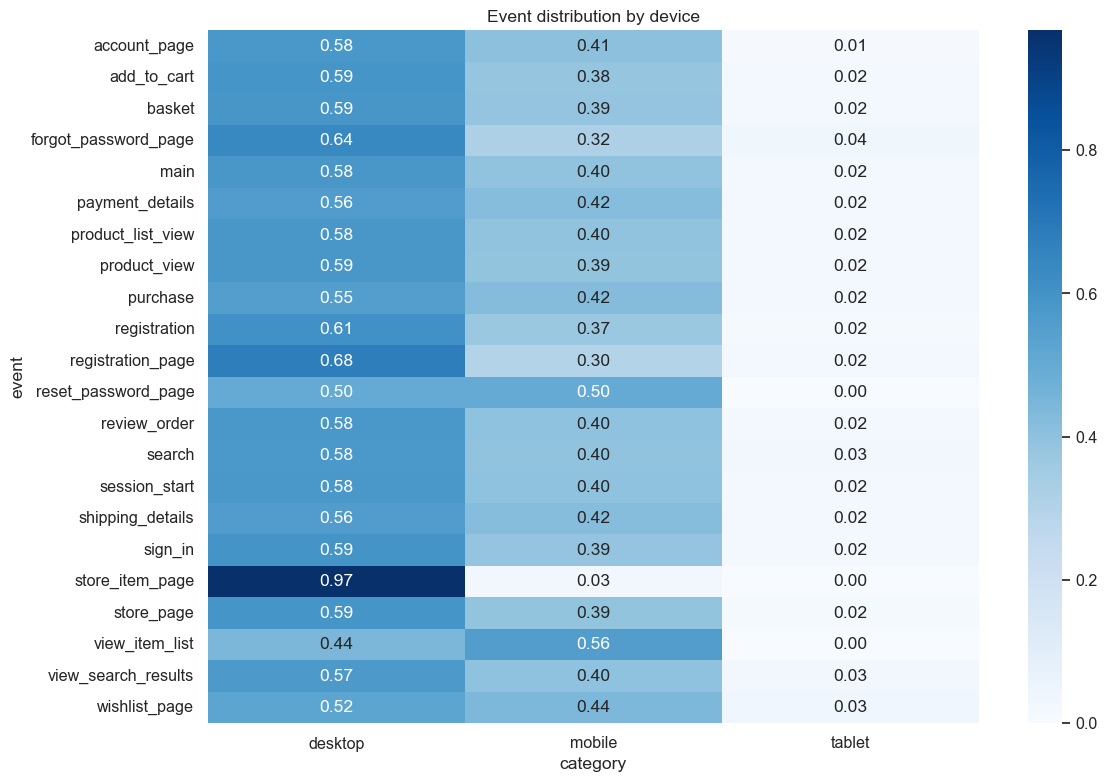

In [91]:
event_device = pd.crosstab(df['event'], df['category'], normalize='index')
plt.figure(figsize=(12,8))
sns.heatmap(event_device, annot=True, cmap='Blues', fmt='.2f')
plt.title('Event distribution by device')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}event_device_heatmap.png')
plt.show()

- Most events follow a stable baseline: ~58% desktop, ~40% mobile, ~2% tablet.
- Notable deviations:
  - `store_item_page` → 97% desktop (almost exclusive).
  - `view_item_list` → 56% mobile (mobile‑first).
  - `reset_password_page` → 50% desktop, 50% mobile.
  - `registration_page` → 68% desktop, 30% mobile.

Device influences certain actions. For Markov modeling, we may either build separate transition matrices by device or add `category` as an additional state dimension. This plot justifies considering device as a segmentation variable.